In [1]:
import json
import os
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import Adam
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [ ]:
from modulars import load_config
from modulars.utils import gaussian_1d
from modulars.utils import pushforward_exp_mean_std
from modulars.utils import traces_to_lambda_moments

In [3]:
config_file = '../invgamma_config.json'
config = load_config(config_file)
mu_like = config['mu_like']
sigma_like = config['sigma_like']
alpha_prior = config['alpha_prior']
beta_prior = config['beta_prior']
n_samples = config['n_samples']
grad_samps = config['grad_samps']
max_iters = 100_000#config['max_iters']
adam_step = 5e-4#config['adam_step']

DATA = False
if DATA:
  data = gaussian_1d(n_samples, mu_like, sigma_like=sigma_like).astype(np.float32)
else:
  data = []

In [4]:
def model(y):
    sigmasq = numpyro.sample("sigma_sq", dist.InverseGamma(alpha_prior, beta_prior))
    numpyro.sample('y', dist.Normal(mu_like, jnp.sqrt(sigmasq)), obs=y)

y_data = jnp.array(data)
optimizer = Adam(adam_step)

single_mc_elbo = Trace_ELBO()
multi_mc_elbo = Trace_ELBO(num_particles=100)

def run_restart(seed):
        
    single_mc_guide = AutoNormal(model)
    multi_mc_guide = AutoNormal(model)

    single_mc_svi = SVI(model, single_mc_guide, optimizer, loss=single_mc_elbo)
    multi_mc_svi = SVI(model, multi_mc_guide, optimizer, loss=multi_mc_elbo)

    def run_svi(rng_key, y_data, svi_model):
        @jax.jit
        def run_single_svi_loop(rng_key, y_data):
            svi_state = svi_model.init(rng_key, y_data)
            def body_fn(i, val):
                svi_state, tracker = val
                svi_state, loss = svi_model.update(svi_state, y_data)
                params = svi_model.get_params(svi_state)
                tracker = {
                    'mu_loc': tracker['mu_loc'].at[i].set(params['sigma_sq_auto_loc']),
                    'std_loc': tracker['std_loc'].at[i].set(params['sigma_sq_auto_scale'])
                }
                return svi_state, tracker
            tracker = {
                'mu_loc': jnp.zeros(max_iters),
                'std_loc': jnp.zeros(max_iters)
            }
            final_state, final_tracker = jax.lax.fori_loop(0, max_iters, body_fn, (svi_state, tracker))
            final_elbo = svi_model.evaluate(final_state, y_data)
            return final_elbo, final_tracker
        return run_single_svi_loop(rng_key, y_data)

    single_elbo, single_tracker = run_svi(jax.random.PRNGKey(seed), y_data, single_mc_svi)
    multi_elbo, multi_tracker = run_svi(jax.random.PRNGKey(seed+1000), y_data, multi_mc_svi)
    return single_tracker, multi_tracker

In [5]:
results = []
for seed in tqdm(range(100)):
    result = run_restart(seed)
    results.append(result)

  0%|          | 0/100 [00:00<?, ?it/s]

In [6]:
plt.rcParams.update({'font.size': 20})
# ----------------------------
# unpack results -> stacks
# ----------------------------
single_means, single_stds = [], []
multi_means,  multi_stds  = [], []
for single_tracker, multi_tracker in results:
    # ---- Convert PyMC unconstrained traces -> constrained lambda mean/std traces
    single_mus, single_sigmas = traces_to_lambda_moments(
        single_tracker['mu_loc'], single_tracker['std_loc']
    )
    multi_mus, multi_sigmas = traces_to_lambda_moments(
        multi_tracker['mu_loc'], multi_tracker['std_loc']
    )
    single_means.append(single_mus)
    single_stds.append(single_sigmas)
    multi_means.append(multi_mus)
    multi_stds.append(multi_sigmas)

single_means = np.stack(single_means, axis=0)  # (N, T)
single_stds  = np.stack(single_stds,  axis=0)  # (N, T)
multi_means  = np.stack(multi_means,  axis=0)  # (N, T)
multi_stds   = np.stack(multi_stds,   axis=0)  # (N, T)

N, T = single_means.shape
single_means = single_means.reshape(N, T)
single_stds  = single_stds.reshape(N, T)
multi_means  = multi_means.reshape(N, T)
multi_stds   = multi_stds.reshape(N, T)

x = np.arange(T)

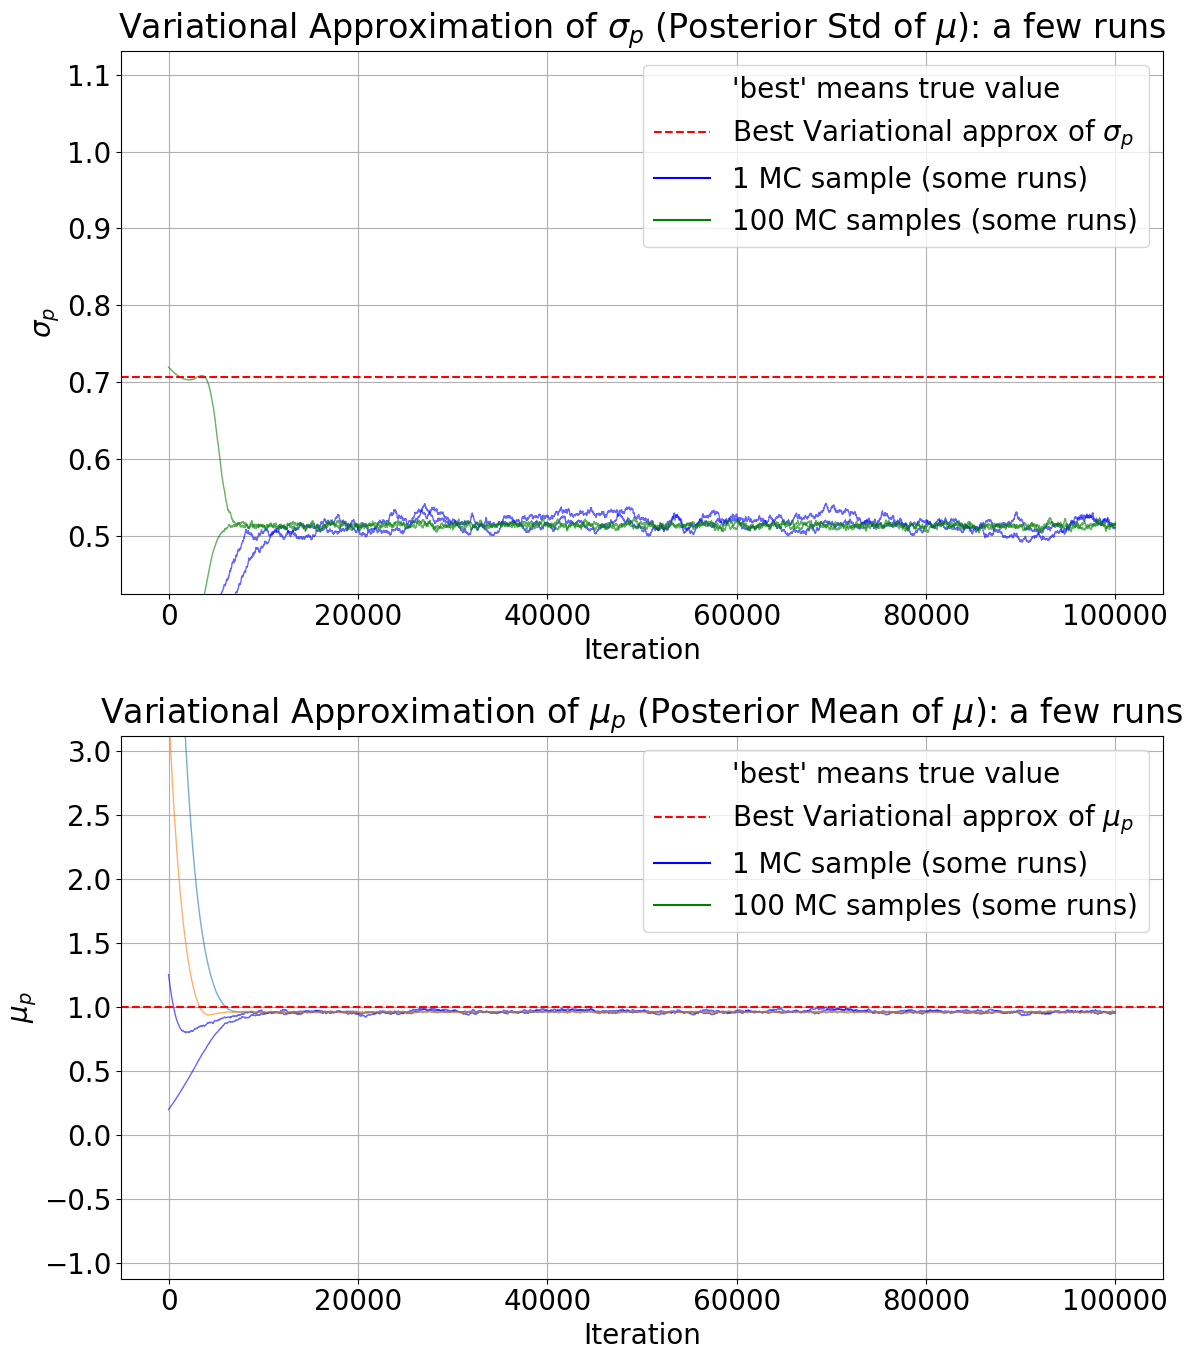

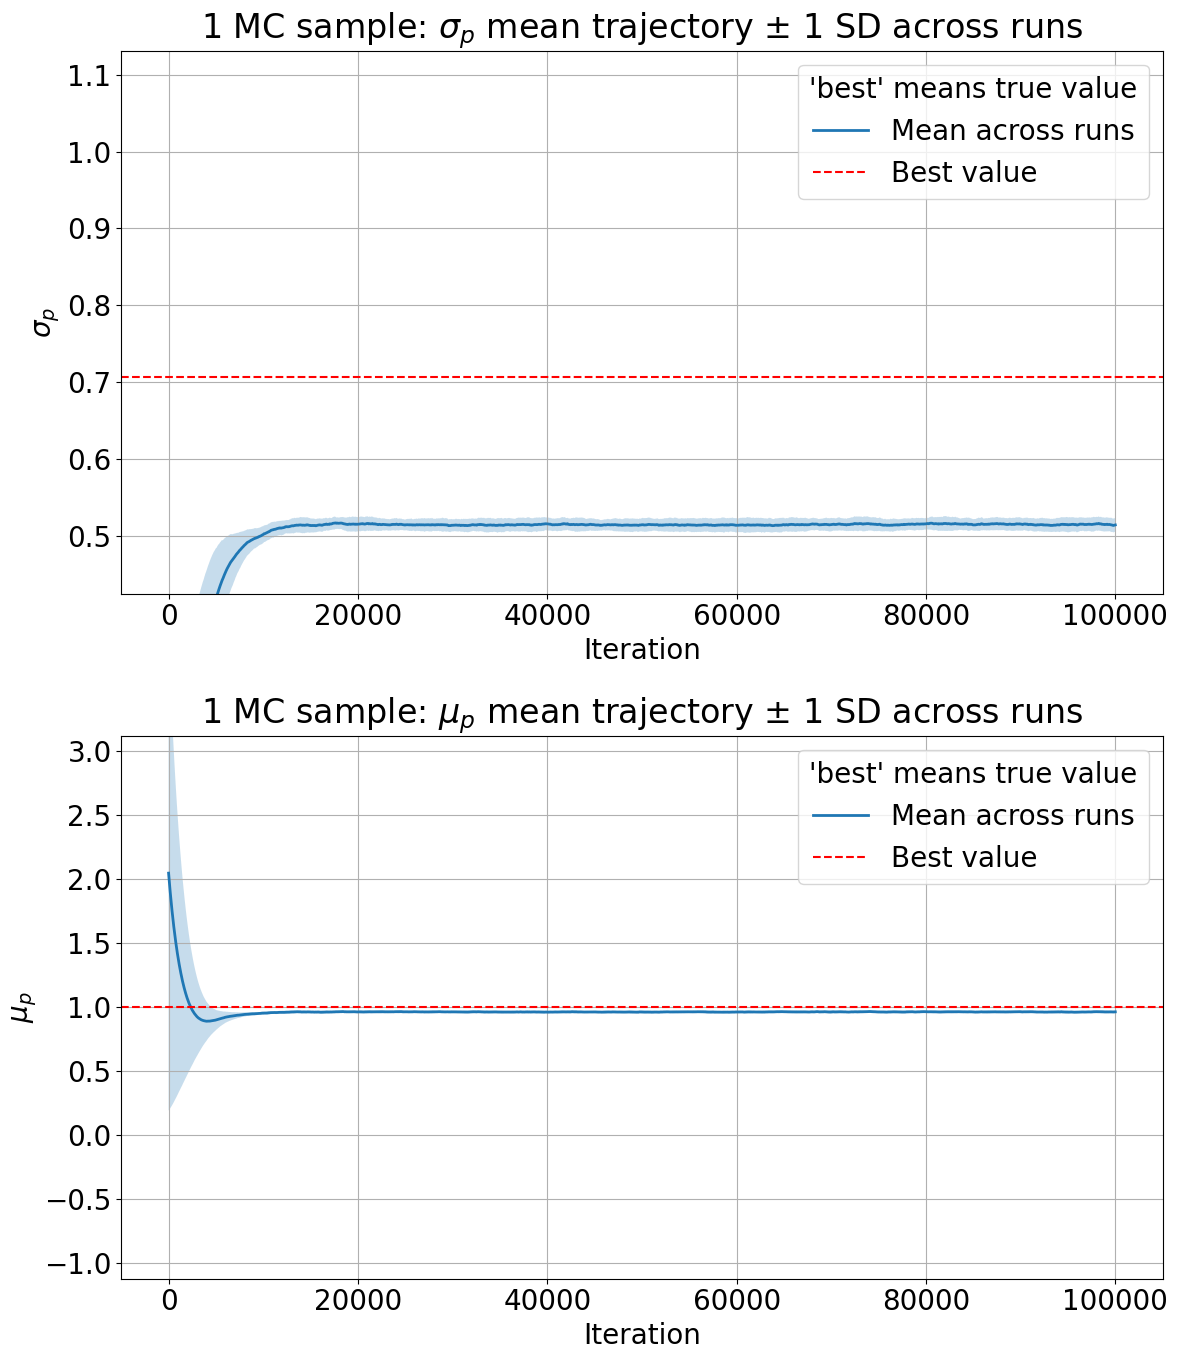

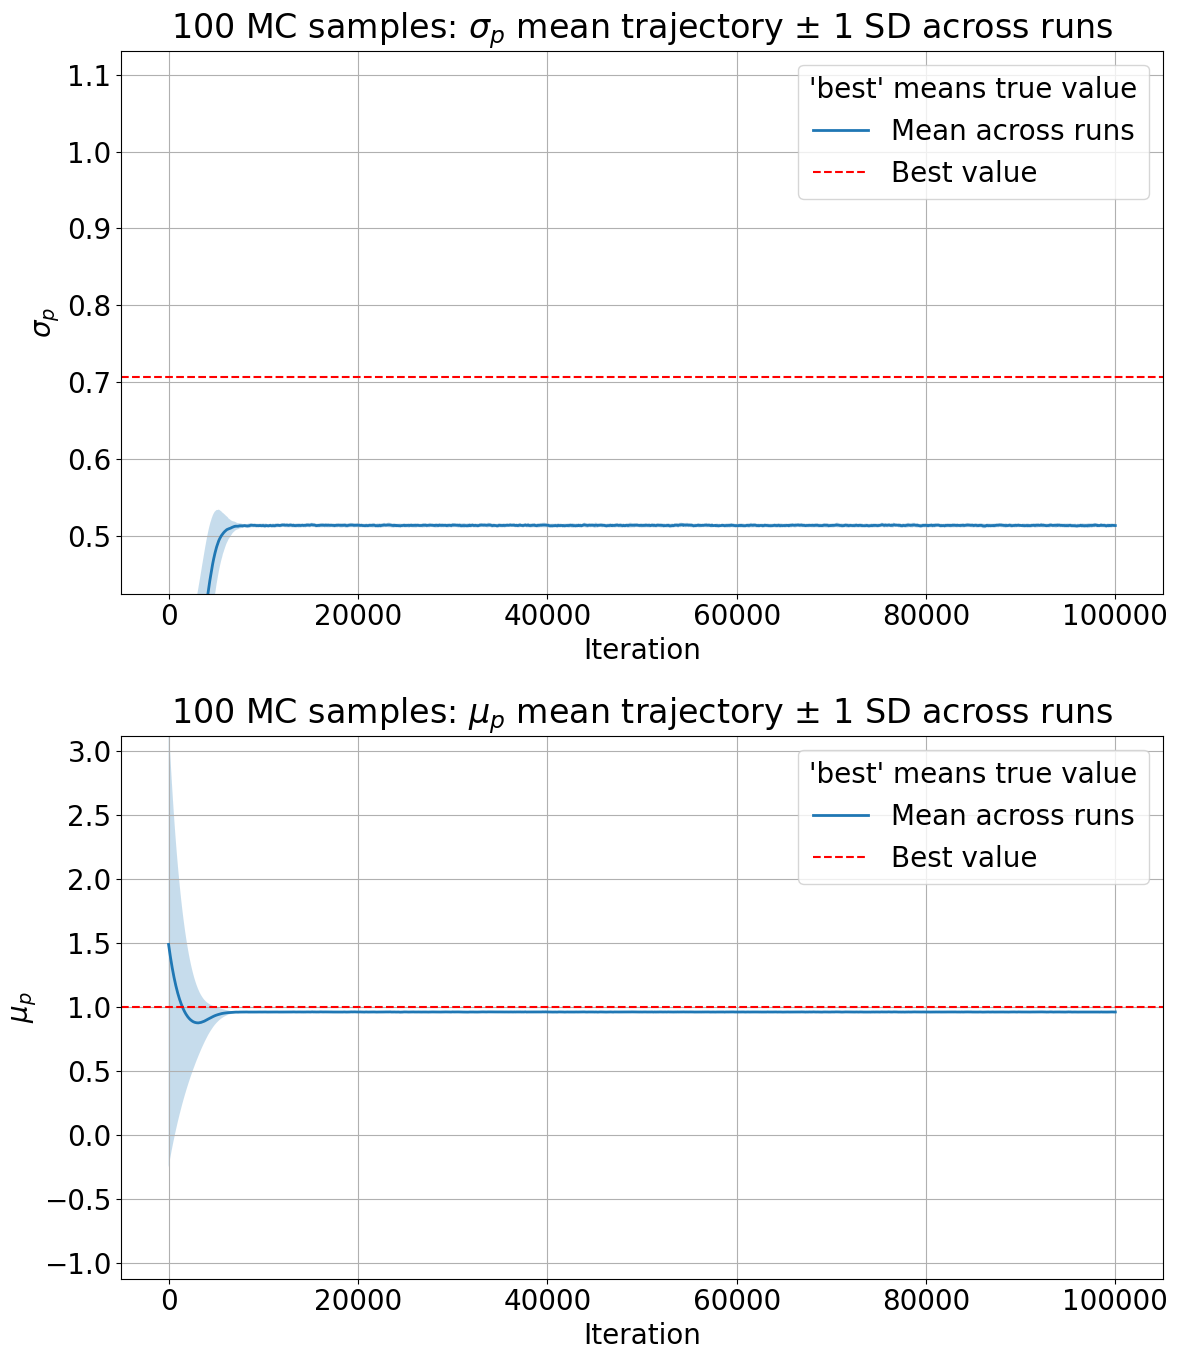

In [7]:
%matplotlib inline
# convert NumPyro traces to lambda moments for plotting
if DATA:
    best_mu_unc = config['best_mean']
    best_sigma_unc = config['best_std']
    best_mu, best_std = pushforward_exp_mean_std(best_mu_unc, best_sigma_unc)
else:
    best_mu = np.divide(beta_prior, (alpha_prior - 1))
    best_std = np.sqrt(
        np.divide(
            beta_prior ** 2,
            (alpha_prior - 1) ** 2 * (alpha_prior - 2)
        )
    )
# ----------------------------
# Plot 1: overlay a few trajectories from each condition
# ----------------------------
k = 2  # how many trajectories to show from each
idx = np.linspace(0, N - 1, k, dtype=int)  # deterministic selection

fig, axs = plt.subplots(2, 1, figsize=(12, 14))

# std of mu
for i in idx:
    axs[0].plot(x, single_stds[i], alpha=0.6, linewidth=1, color='blue')
for i in idx:
    axs[0].plot(x, multi_stds[i],  alpha=0.6, linewidth=1, color='green')

axs[0].axhline(best_std, color='red', linestyle='--', label=r'Best Variational approx of $\sigma_p$')
axs[0].set_title(r'Variational Approximation of $\sigma_p$ (Posterior Std of $\mu$): a few runs')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel(r'$\sigma_p$')
axs[0].grid()
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

# mean of mu
for i in idx:
    axs[1].plot(x, single_means[i], alpha=0.6, linewidth=1, color='blue', label=None)
for i in idx:
    axs[1].plot(x, multi_means[i],  alpha=0.6, linewidth=1, label=None)

axs[1].axhline(best_mu, color='red', linestyle='--', label=r'Best Variational approx of $\mu_p$')
axs[1].set_title(r'Variational Approximation of $\mu_p$ (Posterior Mean of $\mu$): a few runs')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\mu_p$')
axs[1].grid()
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

# manual legend (so we don’t get 16 duplicate entries)
axs[0].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[0].plot([], [], color='green', label='100 MC samples (some runs)')
axs[0].legend(title = "" if DATA else "'best' means true value")

axs[1].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[1].plot([], [], color='green', label='100 MC samples (some runs)')
axs[1].legend(title = "" if DATA else "'best' means true value")

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: mean trajectory ± 1 std band across runs (separate plots for 1-MC and 100-MC)
# ----------------------------
def plot_mean_band(ax, x, Y, true_value, title, ylabel):
    """
    Y: (N, T) trajectories
    """
    m = Y.mean(axis=0)
    s = Y.std(axis=0)
    ax.plot(x, m, linewidth=2, label='Mean across runs')
    ax.fill_between(x, m - s, m + s, alpha=0.25)
    ax.axhline(true_value, color='red', linestyle='--', label='Best value')
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.grid()
    ax.legend(title = "" if DATA else "'best' means true value")

# 1 MC sample: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, single_stds, best_std,
    r'1 MC sample: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

plot_mean_band(
    axs[1], x, single_means, best_mu,
    r'1 MC sample: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

plt.tight_layout()
plt.show()

# 100 MC samples: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, multi_stds, best_std,
    r'100 MC samples: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

plot_mean_band(
    axs[1], x, multi_means, best_mu,
    r'100 MC samples: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

plt.tight_layout()
plt.show()